# Day 4 — Feature Engineering & Hyperparameter Tuning

## Can better features and better settings improve our model?

A machine learning model can only learn from the information we give it.
Before choosing a more complicated algorithm, we should ask whether the
features themselves contain enough useful information.

Today, we will first engineer new features from the Titanic dataset.
Then, instead of manually choosing model settings, we will use
GridSearchCV to systematically search for better hyperparameters.

The goal is not simply to find the highest score, but to understand
which changes actually improve generalization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

## What information does the model currently have?

We will continue using the Titanic dataset. Before engineering features,
we first inspect the available columns and identify information that could
potentially be transformed into more meaningful predictors.

In [2]:
df = pd.read_csv("../../Week 1/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


In [4]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [5]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

## Can two simple columns tell us more when combined?

`SibSp` and `Parch` describe different types of family relationships.
Individually, they may not fully represent the passenger's family
situation.

We can combine them into `FamilySize` to represent the total number of
people in the passenger's immediate family, including the passenger.

We can then derive `IsAlone` from `FamilySize` to distinguish passengers
travelling alone from those travelling with family.

These features add domain-informed information without collecting any
new data.

In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,0,0,1,1
1,1,0,2,0
2,0,0,1,1
3,0,0,1,1
4,1,1,3,0
5,0,0,1,1
6,0,0,1,1
7,1,1,3,0
8,0,0,1,1
9,2,0,3,0


## Does feature engineering actually improve the model?

Creating a feature does not automatically make a model better.

To test whether our engineered features add useful information, we will
compare a baseline Random Forest with a version that also receives
`FamilySize` and `IsAlone`.

Both models will use the same train/validation split so that the
comparison is fair.

In [7]:
numeric_df = df.select_dtypes(include=["number"])

X = numeric_df.drop("Survived", axis=1)
y = numeric_df["Survived"]

X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (250, 8)
X_val  : (84, 8)
X_test : (84, 8)



## Before tuning: how good is the baseline?

Before searching for better hyperparameters, we need a baseline model.
This gives us a reference point for measuring whether our later changes
actually improve performance.

We will use a Random Forest with its standard settings and evaluate it
on the validation set using F1-score.

In [8]:
baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_val)

baseline_f1 = f1_score(y_val, baseline_pred)

print("Baseline Validation F1:", baseline_f1)

Baseline Validation F1: 0.4727272727272727


## Can systematic tuning improve the baseline?

The baseline Random Forest achieved a validation F1-score of approximately
0.473.

Instead of choosing hyperparameters manually, we will use GridSearchCV.
It will test multiple combinations of hyperparameters using 5-fold
cross-validation and select the combination with the best average F1-score.

The parameters we will explore are:

- `n_estimators`: number of trees in the forest
- `max_depth`: maximum depth of each tree
- `min_samples_split`: minimum number of samples required to split a node

This allows us to search systematically rather than relying on trial and
error.

In [9]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Contro

In [10]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 100}
Best CV F1 Score: 0.46291000271076166


In [11]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_val)

tuned_f1 = f1_score(y_val, tuned_pred)

print("Tuned Validation F1:", tuned_f1)

Tuned Validation F1: 0.4528301886792453


In [12]:
max_depth = 10
min_samples_split = 10
n_estimators = 100

## Did tuning actually improve the model?

The baseline Random Forest achieved a validation F1-score of 0.473.

After applying GridSearchCV with 5-fold cross-validation, the best
hyperparameter combination was:

- `n_estimators = 100`
- `max_depth = 10`
- `min_samples_split = 10`

The best cross-validation F1-score was 0.463, while the tuned model
achieved a validation F1-score of 0.453.

Therefore, hyperparameter tuning did not improve the validation result in
this experiment. The baseline model performed slightly better.

This is an important result because hyperparameter tuning does not
guarantee improvement. The search can identify the best configuration
within the tested grid, but that configuration may still perform worse
than the baseline on a separate validation set.

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance

,Feature,Importance
5,Fare,0.306502
0,PassengerId,0.235320
2,Age,0.214000
6,FamilySize,0.063912
1,Pclass,0.051214
3,SibSp,0.044902
4,Parch,0.042325
7,IsAlone,0.041826


## Which features mattered most?

The tuned Random Forest ranked `Fare`, `PassengerId`, and `Age` as the
three most important features.

Among the engineered features, `FamilySize` had a higher importance
(approximately 0.064) than `IsAlone` (approximately 0.042).

This suggests that the total family size provided more useful information
to the model than simply knowing whether a passenger was travelling alone.

However, feature importance should not be interpreted as proof of
causation. It only describes how much the feature contributed to the
model's decision process.

The high importance of `PassengerId` is also a reason to be cautious:
PassengerId is an identifier rather than a meaningful passenger
characteristic, so its predictive importance may reflect patterns in
this particular dataset rather than a useful real-world relationship.

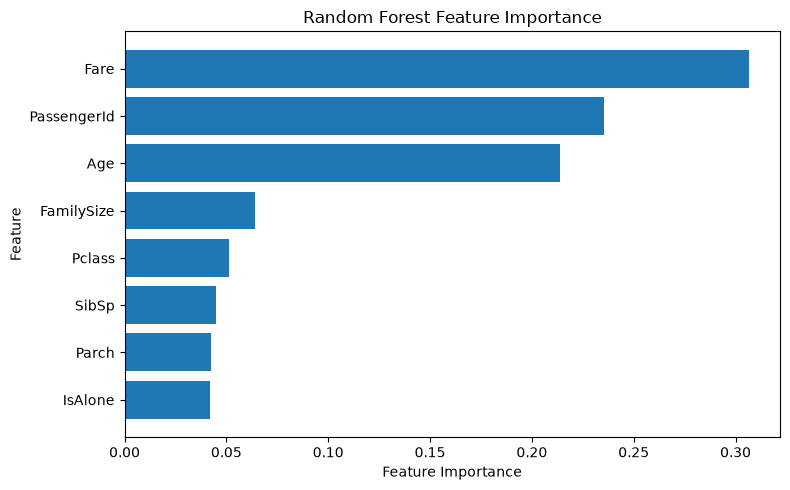

In [14]:
feature_importance_plot = feature_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

### What does the visualization tell us?

The visualization makes the feature ranking easier to compare.

`Fare` has the highest importance among the available features, followed
by `PassengerId` and `Age`. The engineered `FamilySize` feature ranks
above `IsAlone`, suggesting that family size carries more information for
this model.

However, the importance values alone do not guarantee better predictive
performance. Our validation results showed that the tuned model did not
outperform the baseline, demonstrating that adding features and tuning
hyperparameters does not automatically lead to a better model.

In [15]:
final_test_pred = best_model.predict(X_test)

final_test_f1 = f1_score(y_test, final_test_pred)

print("Final Test F1:", final_test_f1)

Final Test F1: 0.5384615384615384


## Final Evaluation on the Test Set

After completing feature engineering and hyperparameter tuning, the final
model was evaluated on the held-out test set.

The final test F1-score was **0.538**.

The test set was kept separate during model development and was evaluated
only after the feature engineering and hyperparameter selection decisions
were completed. This provides a more honest estimate of how the final
model performs on unseen data.

The result also shows why validation and test sets have different roles:
validation data helps us make development decisions, while the test set is
reserved for the final evaluation.

# Day 4 Summary

Today demonstrated that improving a machine learning solution is not only
about selecting a more complex model.

We created two engineered features, `FamilySize` and `IsAlone`, to provide
the Random Forest with additional information about family relationships.

The baseline Random Forest achieved a validation F1-score of **0.473**.
GridSearchCV tested multiple hyperparameter combinations using 5-fold
cross-validation and selected:

- `n_estimators = 100`
- `max_depth = 10`
- `min_samples_split = 10`

The best cross-validation F1-score was **0.463**, while the tuned model
achieved **0.453** on the validation set. Therefore, tuning did not improve
the validation score compared with the baseline.

Among the engineered features, `FamilySize` had greater feature
importance than `IsAlone`, suggesting that it contributed more to the
model's decisions in this experiment.

Finally, the tuned model achieved a **test F1-score of 0.538** on the
held-out test set.

The main lesson is that feature engineering and hyperparameter tuning are
experiments, not guarantees of improvement. A strong machine learning
workflow requires testing whether each change actually improves
generalization rather than assuming that more tuning will always produce
a better model.